In [1]:
%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


While physical processes are time-contiunous and have continuous values, 
DSP systems usually work with signals that are both discrete in time and values.
Converting a signal from the physical domain - for example sound or voltage - to the digital domain - for example buffer in a computer's memory- 
involves two basic operations:

- **Sampling**  is the process of measuring the value of a (physical) signal at equidistant time instances. The sampling process has a direct impact on the temporal resolution of the digital signal.

- **Quantization** is the process of converting continuous values of a signal to a finite set of discrete values.

-----

The process of converting a physical signal $x(t)$ to a time-discrete and quantized array of values $x^*[n]$ is represented by the following flow chart:

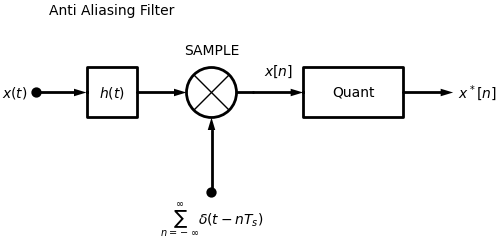

In [3]:
import schemdraw
from schemdraw import flow
from schemdraw import dsp

with schemdraw.Drawing() as d:
    schemdraw.config(fontsize=10, unit=1)
    flow.Dot().label('$x(t)$',loc='left')
    flow.Arrow().length(d.unit)  
    dsp.Square().label('$h(t)$').label('Anti Aliasing Filter',loc='top', ofst=1)
    flow.Arrow().length(d.unit)  
    
    mix = dsp.Mixer().label('SAMPLE')
   
    flow.Dot().at((3.5,-2)).label('$\sum_{n=-\infty}^{\infty} \delta(t-nT_s)$',loc='bottom')

    
    dsp.Arrow().up(1.5)
    
    #dsp.Line().at(mix.S).down(d.unit/3)
    
    dsp.Line().at(mix.E).right(d.unit/3)
    flow.Arrow().length(d.unit).label('$x[n]$') 
    
    flow.Process(w=2,h=1).label('Quant')
    flow.Arrow().length(d.unit).label('$x^*[n]$',loc='right') 

-----

The anti-aliasing filter $h(t)$ discards frequencies that are too high for the sampling rate $f_s$ of the system. This will be treated in more detail with the *Nyquist–Shannon Sampling Theorem*.
The actual sampling is modelled as a multiplication of $x(t)$ with a series of equidistant Dirac impulses with a distance of $T_s = \frac{1}{f_s}$. 
The sampled signal is then quantized.

-----

Many aspects of both sampling and quantization belong to the discipline of audio technology and electrical engineering, rather than digital signal processing.
The paradigms and circuits for implementing them are thus not in the scope of this DSP section. 
However, both proceees are essential for the qualities of digital signals and systems.
They define the limits and boundaries of DSP applications and are thus crucial for understanding and designing algorithms.
